In [2]:

%matplotlib inline
import jax.numpy as jnp
from jax import value_and_grad
from jax import grad
from jax import random
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as snb
import numpy as np


###Bayesian ML functions###

from bayesian_ml import *
from packages.BayesianLinearRegression import BayesianLinearRegression
from packages.LogisticRegression import LogisticRegression
from packages.Grid2D import Grid2D
from packages.LaplaceApproximation import LaplaceApproximation
from packages.PosteriorPredictiveDistribution import PosteriorPredictiveDistribution
from packages.Hyperparameters import Hyperparameters
from packages.StationaryIsotropicKernel import StationaryIsotropicKernel
from packages.GaussianProcessRegression import GaussianProcessRegression
from packages.BayesianLinearSoftmax import BayesianLinearSoftmax
from packages.metropolis import metropolis



###Distributions###
from scipy.stats import multivariate_normal as mvn
from scipy.stats import poisson
from scipy.stats import norm



snb.set_theme(font_scale=1.25)

# Bayesian Linear Regression

<h3> Insert data <h3>

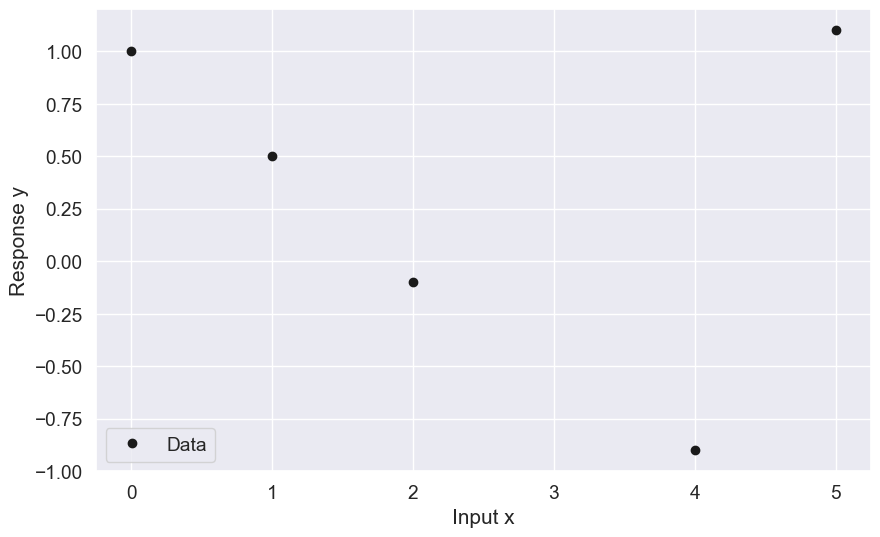

In [2]:
################
##TRANING DATA##
################

xtrain = jnp.array([0.0, 1.0, 2.0, 4.0, 5.0])[:, None]
ytrain = jnp.array([1.0, 0.5, -0.1, -0.9, 1.1])[:, None]

#################
##Design Matrix##
#################
 
def design_matrix(x):
    return jnp.column_stack((jnp.ones(len(x)), x))
fig, ax = plt.subplots(1,1, figsize=(10, 6))
plot_toydata(ax, xtrain=xtrain, ytrain=ytrain)



<h3> Compute linear regression <h3>

In [3]:
Phi_train = design_matrix(x = xtrain)

###############################. ######################################
##alpha = inverse prior sigma##  ##beta = inverse likelihood variance##
###############################. ######################################

alpha = 1 / 2
sigma = 1/ 5
model = BayesianLinearRegression(Phi = Phi_train, y = ytrain, alpha = alpha, beta = 1 / sigma**2)

dim = 4
w_MLE = model.w_MLE()
w_MAP = model.w_MAP(dim = dim)


import numpy as np

np.set_printoptions(precision=4, suppress=True)

print("=" * 40)
print("  Bayesian Linear Regression Results")
print("=" * 40)
print(f"  w_MLE     : {w_MLE}")
print(f"  w_MAP     : {w_MAP}  (dim={dim})")
print("=" * 40)

TypeError: add got incompatible shapes for broadcasting: (4, 4), (2, 2).

<h3>Visualization of plug-in approximations and predictive posterior<h3>

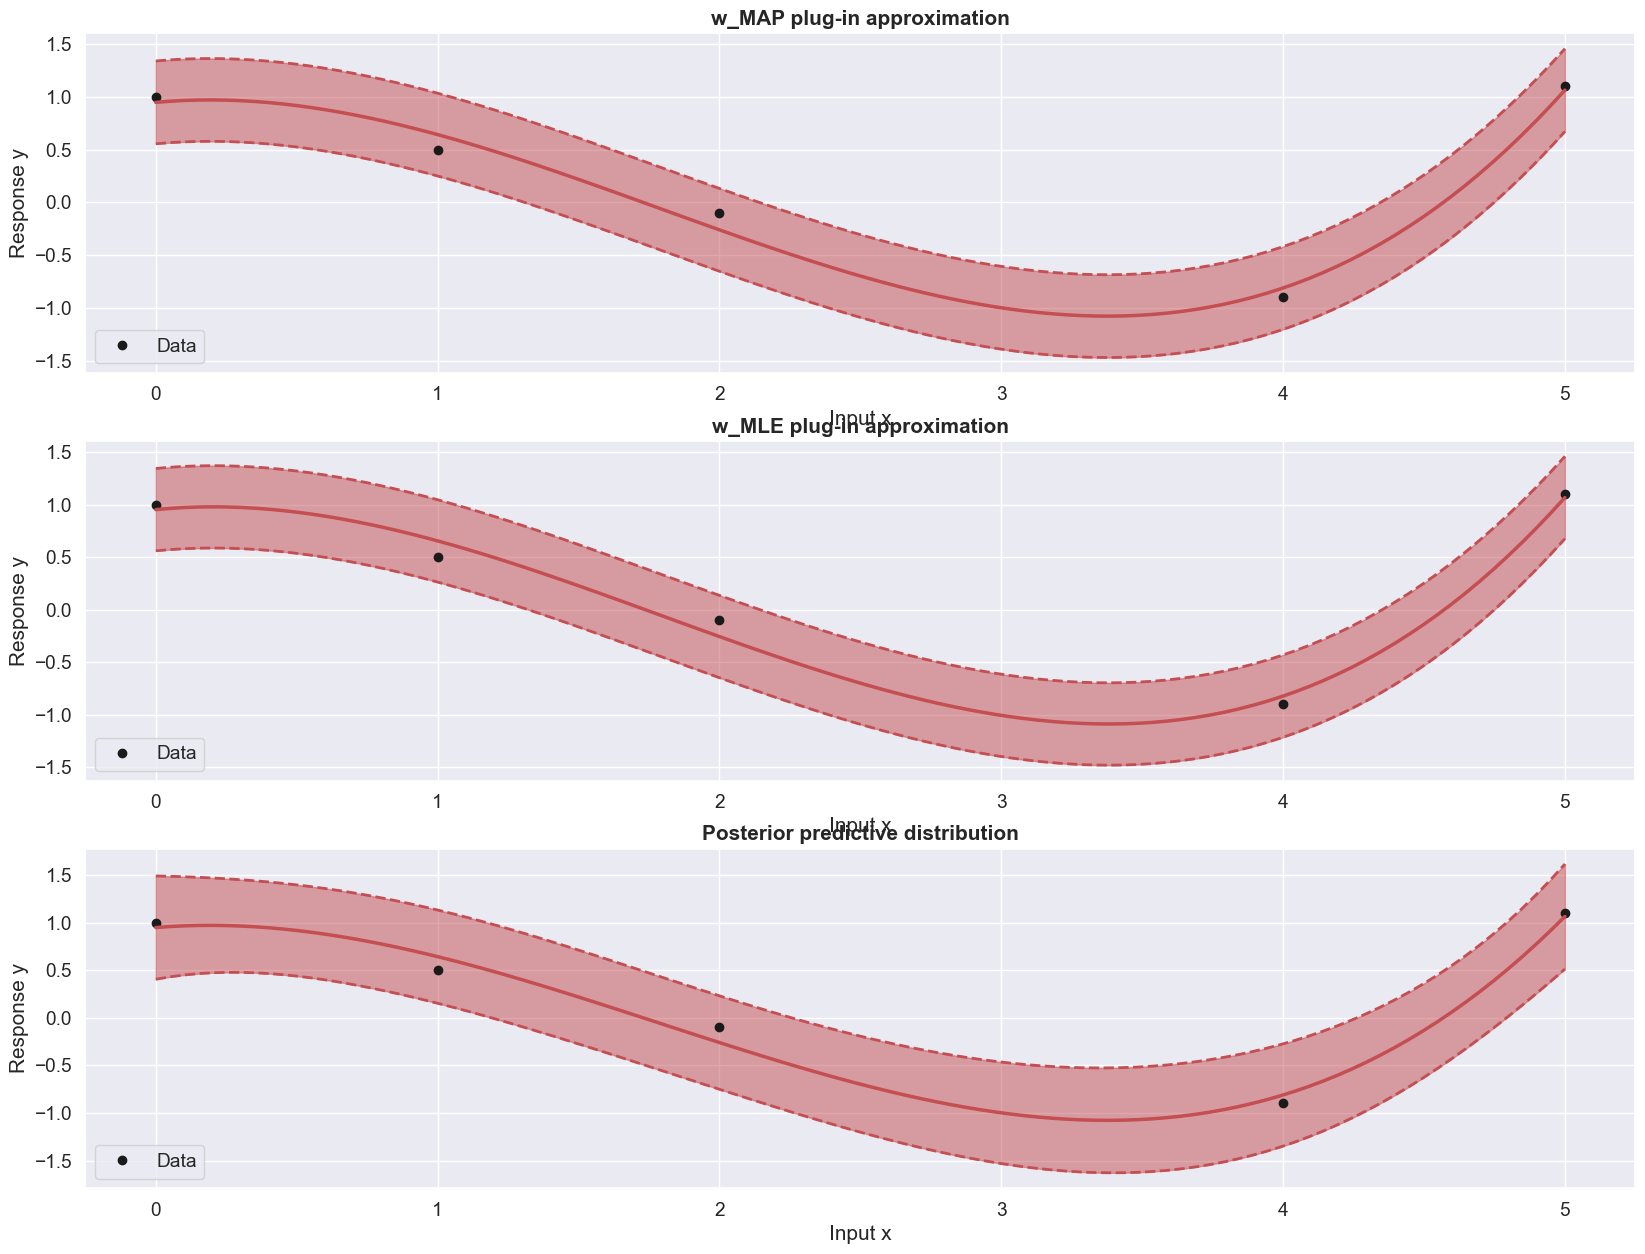

In [ ]:
xpred = jnp.linspace(0, 5, 100)

Phi_pred = design_matrix(xpred)

mu_map, var_map = model.predict_y_MAP(Phi_pred)
mu_mle, var_mle = model.predict_y_MLE(Phi_pred)
mu_y, var_y = model.predict_y(Phi_pred)

fig, ax = plt.subplots(3, 1, figsize=(20,15))

plot_toydata(ax[0], xtrain=xtrain, ytrain=ytrain)
plot_toydata(ax[1], xtrain=xtrain, ytrain=ytrain)
plot_toydata(ax[2], xtrain=xtrain, ytrain=ytrain)
plot_predictions(ax=ax[0],x=xpred, mu = mu_map, var = var_map)
plot_predictions(ax=ax[1],x=xpred, mu = mu_mle, var = var_mle)
plot_predictions(ax=ax[2],x=xpred, mu = mu_y, var = var_y)
ax[0].set_title('w_MAP plug-in approximation', fontweight='bold');
ax[1].set_title('w_MLE plug-in approximation', fontweight='bold');
ax[2].set_title('Posterior predictive distribution', fontweight='bold');

# Logistic regression

<h3> Insert data <h3>

In [ ]:
Xtrain = jnp.array([[0,0], [1,1]])
ytrain = jnp.array([0,1])

<h3> Create model (remember correct prior variance) <h3>

This is grad [[1. 1.]]
This is grad [[0.2082 0.2082]]
This is grad [[0.0573 0.0573]]
This is grad [[0.0066 0.0066]]
This is grad [[0.0002 0.0002]]
This is grad [[0. 0.]]


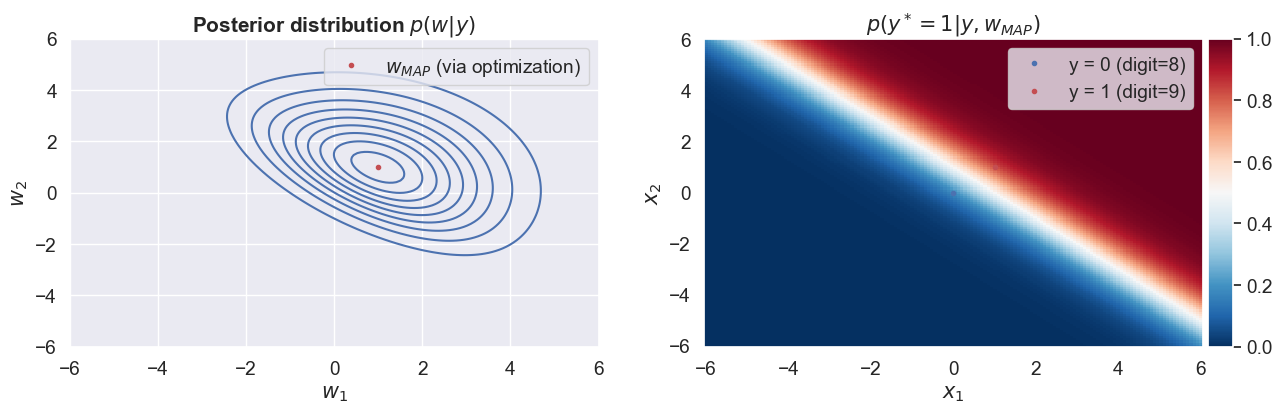

In [ ]:
model = LogisticRegression(Xtrain, ytrain, alpha = 1/4)
w_MAP = jnp.array([0.74077, 0.74077])
pred_MAP = lambda x: model.predict(model.preprocess(x), w_MAP)

# prep grid
dim1, dim2 = jnp.linspace(-6, 6, 150), jnp.linspace(-6, 6, 149)
grid_log_joint = Grid2D(dim1, dim2, model.log_joint, name='Posterior distribution $p(w|y)$')
grid_predictions = Grid2D(dim1, dim2, pred_MAP, name='$p(y^*=1|y, w_{MAP})$')

# plot
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
grid_log_joint.plot_contours(ax[0], f=jnp.exp,)
ax[0].plot(model.w_MAP[0], model.w_MAP[1], 'r.', label='$w_{MAP}$ (via optimization)')
ax[0].legend()

plot_data(ax[1], Xtrain, ytrain, 'Training data')
grid_predictions.plot_heatmap(ax[1], colorbar=True)
ax[1].set(xlabel='$x_1$', ylabel='$x_2$');

<h3> Evaluate log-joint <h3>

In [ ]:
model.log_joint(w = jnp.array([[0.74077, 0.74077]]))

Array([-3.771], dtype=float64)

<h3> Gradient and Hessian <h3>

In [ ]:
######################################
#Insert either w_MAP, w from exercise#
######################################

nabla = model.grad(w = w_MAP[None, :])

This is grad [[0.1852 0.1852]]


In [ ]:
cov = jnp.linalg.inv(-model.hessian(w = w_MAP))

This is H [[-0.5518 -0.3018]
 [-0.3018 -0.5518]]


<h3>Plot of Laplace approxmation of posterior<h3>

- If $w_{MAP}$ in exercise is where $\nabla_{w} = 0$ use LaplaceApproximationClass
- Else use dist

In [ ]:
lap_approx = LaplaceApproximation(model=model)
dist = multivariate_normal(mean = model.w_MAP, cov = cov)

This is H [[-0.4655 -0.2155]
 [-0.2155 -0.4655]]


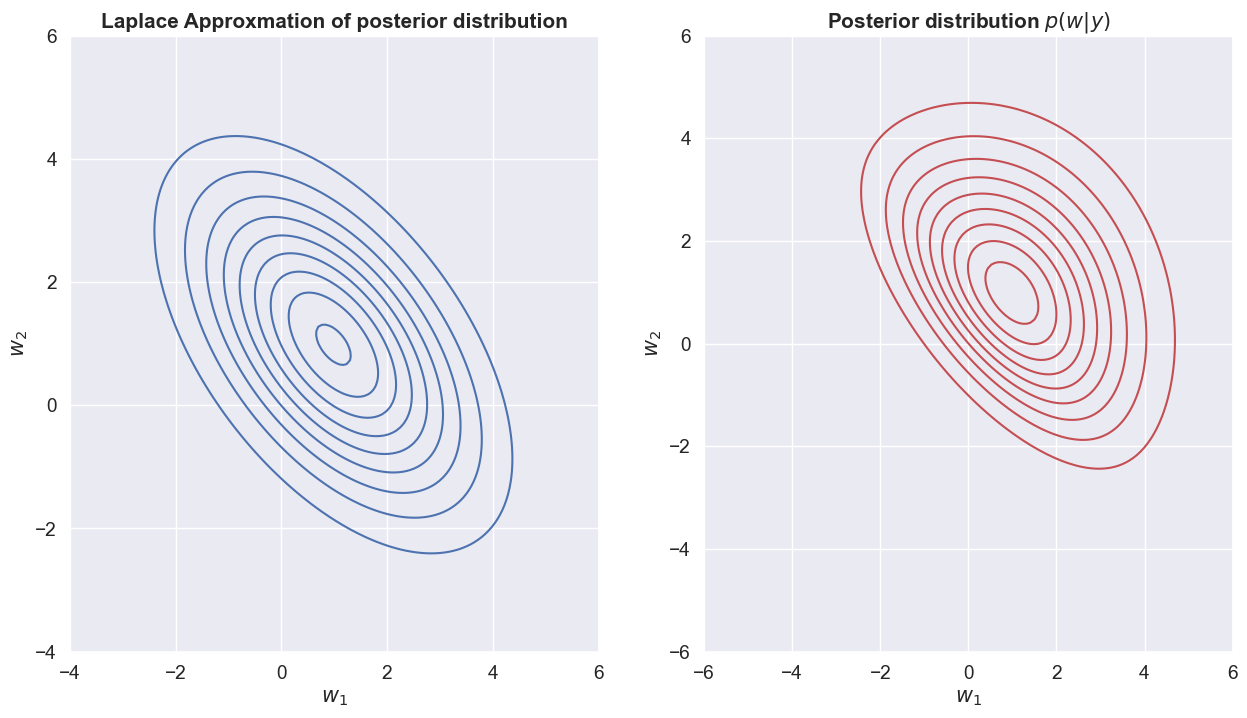

In [ ]:
dim1, dim2 = jnp.linspace(-4, 6, 150), jnp.linspace(-4, 6, 149)
grid_laplace_posterior = Grid2D(dim1, dim2, dist.pdf, name='Laplace Approxmation of posterior distribution')


fig, ax = plt.subplots(1, 2, figsize=(15, 8))
grid_laplace_posterior.plot_contours(ax[0])
grid_log_joint.plot_contours(ax[1],f = jnp.exp, color = "r")



<h3> Posterior Predictive Distribution <h3>

In [ ]:
xtrain.shape

(5, 1)

In [ ]:
postpred = PosteriorPredictiveDistribution(model)

pred_dict = {   'Plug-in approx': postpred.plugin_approx,
                'Probit approx':  postpred.probit_approx,
                'Monte Carlo':    postpred.montecarlo,
            }


This is H [[-0.4655 -0.2155]
 [-0.2155 -0.4655]]


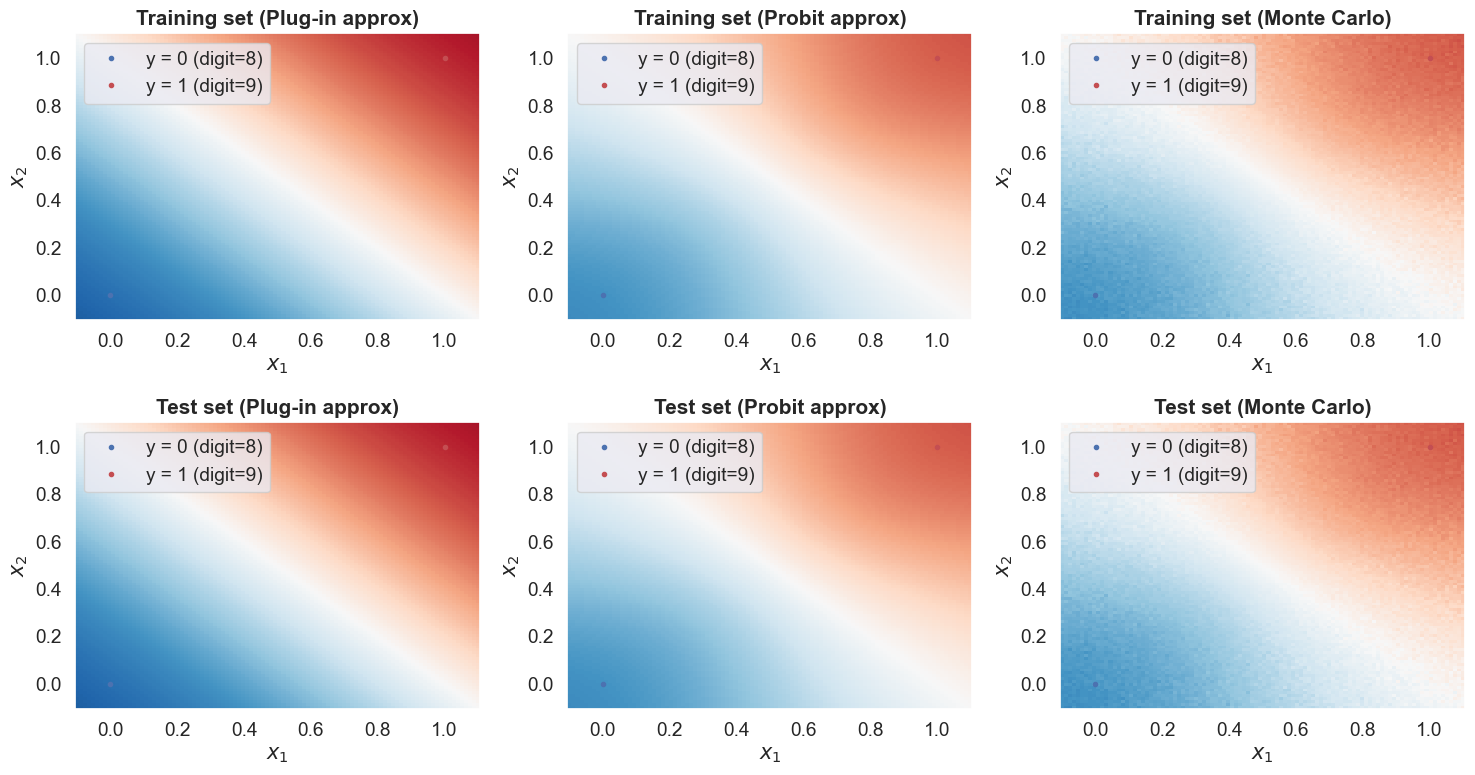

In [ ]:


dim1 = jnp.linspace(Xtrain[:, 0].min()-0.1, Xtrain[:, 0].max()+0.1, 100)
dim2 = jnp.linspace(Xtrain[:, 1].min()-0.1, Xtrain[:, 1].max()+0.1, 100)

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
    
for i, (name, predict_func) in enumerate(pred_dict.items()):
    predict_grid = Grid2D(dim1, dim2, predict_func)

    plot_data(ax[0, i], Xtrain, ytrain, alpha=0.5)
    plot_data(ax[1, i], Xtrain, ytrain, alpha=0.5)
    predict_grid.plot_heatmap(ax[0, i])
    predict_grid.plot_heatmap(ax[1, i])
    ax[0, i].set_title(f'Training set ({name})', fontweight='bold')
    ax[1, i].set_title(f'Test set ({name})', fontweight='bold')
    ax[0, i].set(xlabel='$x_1$', ylabel='$x_2$')
    ax[1, i].set(xlabel='$x_1$', ylabel='$x_2$')


fig.tight_layout()


# Gaussian Process Regression

<h3> Kernels <h3>

In [ ]:
# in the code below tau represents the distance between to input points, i.e. tau = ||x_n - x_m||.
def squared_exponential(tau, hyperparameters):
    return hyperparameters.kappa**2*jnp.exp(-0.5*tau**2/hyperparameters.lengthscale**2)

def matern12(tau, hyperparameters):
    return hyperparameters.kappa**2*jnp.exp(-tau/hyperparameters.lengthscale)

def matern32(tau, hyperparameters):
    return hyperparameters.kappa**2*(1 + jnp.sqrt(3)*tau/hyperparameters.lengthscale)*jnp.exp(-jnp.sqrt(3)*tau/hyperparameters.lengthscale)

<h3> Insert your data <h3>

In [ ]:
######################
##Data from exercise##
######################

Xtrain = jnp.array([-2, 0,2])[:, None]
ytrain = jnp.array([ -2.01, 1.41, 0.23])[:, None]

<h3> Define model <h3>


In [ ]:
# instantiate  kernel objects
kernel = StationaryIsotropicKernel(squared_exponential)

# specify hyperparameters
hyper = Hyperparameters(kappa=jnp.sqrt(2), lengthscale=2, sigma=1/2)


# instantiate GP without data (hence, posterior=prior) and with data
gp = GaussianProcessRegression(Xtrain, ytrain, kernel, hyper)


<h3>Plot data with sampled functions<h3>

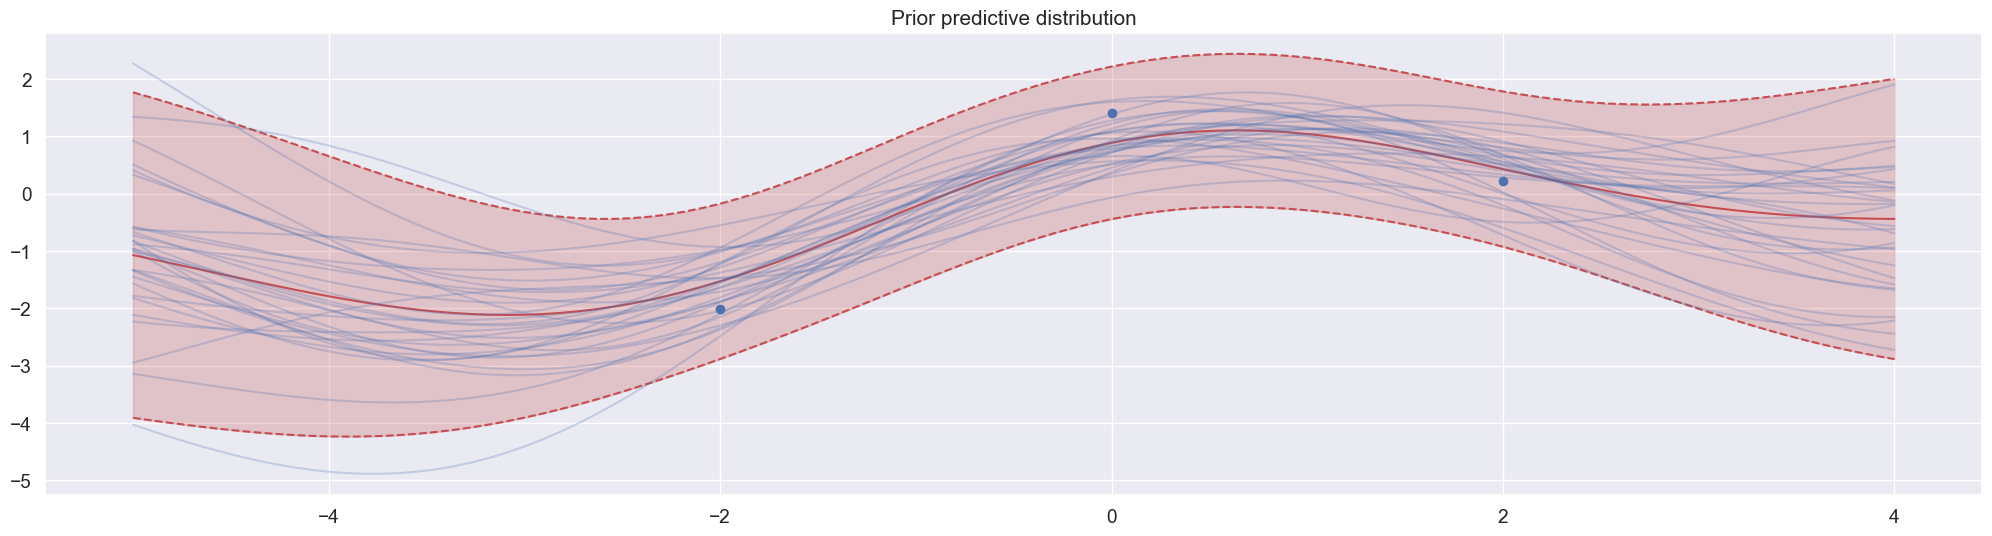

In [ ]:
Xstar = jnp.linspace(-5,4,100)[:, None]
fig, ax = plt.subplots(1, 1, figsize=(25, 6))
plot_with_uncertainty(ax, Xstar, gp, title='Prior predictive distribution', num_samples=30)
ax.scatter(Xtrain, ytrain)



In [ ]:
gp.kernel.construct_kernel(X1 = Xtrain, X2 = Xtrain, hyperparameters=hyper)

Array([[2.00000001, 1.21306132, 0.27067057],
       [1.21306132, 2.00000001, 1.21306132],
       [0.27067057, 1.21306132, 2.00000001]], dtype=float64)

<h2> Metrics <h2>

$$p(y^{*} | x^{*}) - \text{Prior predictive distribution}$$

In [ ]:
gp_prior = GaussianProcessRegression(jnp.zeros((0, 1)), jnp.zeros((0, 1)), kernel, hyper)
gp_prior.predict_y(Xstar = jnp.array([1]))

(Array([[0.]], dtype=float64), Array([[0.53]], dtype=float64))

$$p(y^{*} | \bm{y}, x^{*}) - \text{Posterior predictive distribution}$$

In [ ]:
xstar = 227
gp.predict_y(Xstar = jnp.array([xstar]))

(Array([[0.]], dtype=float64), Array([[0.53]], dtype=float64))

$$\log{p(\bf{y} | \kappa, \ell, \sigma)} - \text{Log marginal likelihood}$$

In [ ]:
gp.log_marginal_likelihood(hyperparameters=hyper)

Array(-6.6512, dtype=float64)

$$p(\bf{f} | \bf{y}, \bf{x})- \text{Posterior distribution}$$

In [ ]:
gp.predict_f(Xstar=Xtrain)

(Array([[-1.52833703],
        [ 0.8865026 ],
        [ 0.42873887]], dtype=float64),
 Array([[ 0.20844192,  0.02778709, -0.00998173],
        [ 0.02778709,  0.19226005,  0.02778709],
        [-0.00998173,  0.02778709,  0.20844192]], dtype=float64))

<h2> Covariance Matrix <h2>

<h3>Define new kernel function <h3>

In [ ]:
def exam_kernel_function(tau, hyperparameters):
    return hyperparameters.c1 * (1 + jnp.abs(tau) / (2*hyperparameters.lengthscale**2))**-1

new_kernel = StationaryIsotropicKernel(exam_kernel_function)

<h3> Define new hyperparameters <h3>

In [ ]:
new_hyper = Hyperparameters(c1 = 1, c2 = 1, lengthscale= 1 / jnp.sqrt(2), kappa = 0)

<h3> Define new gaussian process and new test points <h3>

In [ ]:
gp_new = GaussianProcessRegression(X = Xtrain, y = ytrain, hyperparameters=new_hyper, kernel = new_kernel)

#Give test points from exam
Xtest = jnp.array([-1])[:, None]


gp_new.kernel.construct_exam_kernel(X1=Xtrain, X2 = Xtest, hyperparameters=new_hyper)

Array([[ 2.6308],
       [-1.7394],
       [-0.1809],
       [ 3.3422],
       [ 2.0221],
       [-3.1113],
       [ 5.0562],
       [ 1.7372]], dtype=float64)

# Bayesian Linear Softmax

### Predict $y$ given $\hat{W}_{MAP}$

In [ ]:
design_matrix = lambda x: jnp.column_stack((jnp.ones(len(x)), x))

X = jnp.ones(3)
y = jnp.array([1,2,3])

phi = design_matrix(X)
model = BayesianLinearSoftmax(X = phi, y = y)

#############
####W_MAP####
#############

W_MAP = jnp.array([[-0.5, -2.0],[3,0],[1,1]])

x_star = jnp.array([-1])

phi_star = design_matrix(x_star)

model.predict_y(X_star=phi_star, W_given=W_MAP)

Array([[0.17529039, 0.78559703, 0.03911257]], dtype=float64)

### Monte Carlo estimate of posterior predictive

In [ ]:
W1 = jnp.array([[-0.15, -1.92],[3.2, 0.45],[1.37, 0.8]])
W2 = jnp.array([[-0.31, -2.03], [2.98,0.08],[1.03,1.29]])
W3 = jnp.array([[-0.35, -1.98],[3.09, 0.07],[1.3, 0.96]])

W = jnp.array([W1, W2, W3])

jnp.mean(jnp.array([model.predict_y(X_star=phi_star, W_given=w) for w in W]), axis = 0)

Array([[0.22295359, 0.72390675, 0.05313967]], dtype=float64)

### Entropy and confidence

In [ ]:
###############################
##Insert posterior predictive##
###############################

p_pred = jnp.array([[0, 0.27, 0.73]])

entropy = compute_entropy(p_pred)
confidence = compute_confidence(p_pred)

print(f"Entropy: {entropy[0]:3.2f} \nConfidence: {confidence[0]:3.2f}")

Entropy: 0.58 
Confidence: 0.73


# MCMC

In [23]:
alpha = 8
x = jnp.array([1,2,3])
y = jnp.array([10,4,1])

log_prior = lambda w: mvn.logpdf(w, jnp.zeros(2), jnp.eye(2) * alpha**(-1))
log_likelihood = lambda w: jnp.sum(poisson.logpmf(y, jnp.exp(3 + w[0] * x + w[1] * x**2)))

log_target = lambda w: log_prior(w) + log_likelihood(w) 
mcmc = metropolis(log_target=log_target, tau = 1, num_params=2, num_iter=10**4, theta_init=jnp.array([0,0]), dis_prop= 0.5)

Acceptance ratio: 0.04


In [24]:
mcmc.credability_interval(p = jnp.array([0.05, 0.95]))

[Array([-0.64743974,  0.10840033], dtype=float64),
 Array([-0.51015329, -0.09929814], dtype=float64)]

### Plot of trace

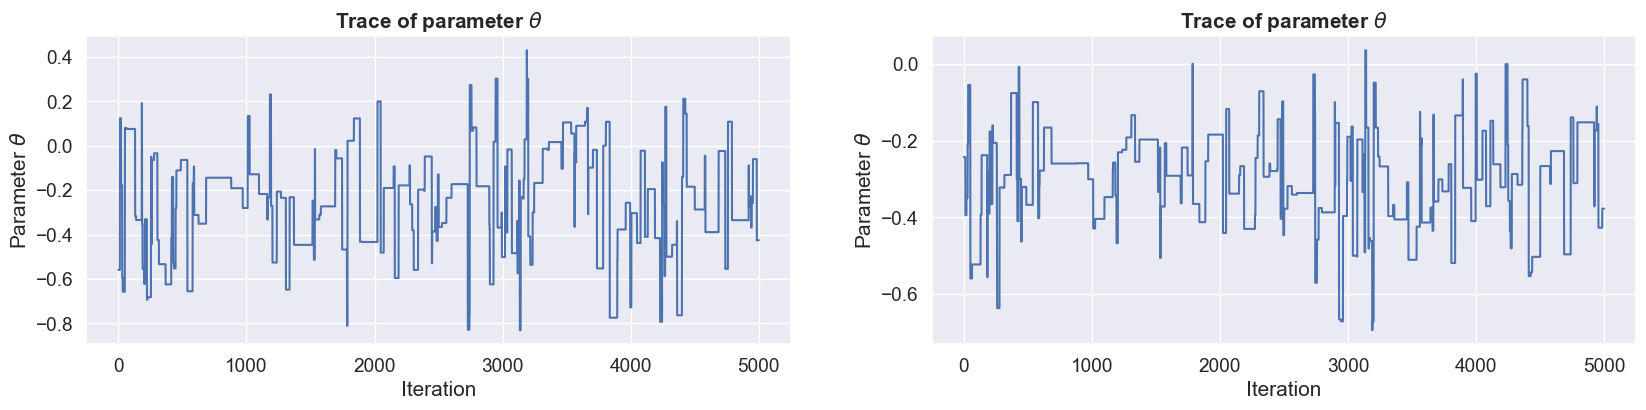

In [25]:
mcmc.plot_trace()

### Probability of paramater above a certain value

In [26]:
w1 = mcmc.post_warmup_thetas[:,0]
jnp.mean(w1 > 0)

Array(0.14957008, dtype=float32)

In [36]:
x = 1.5
samples = mcmc.post_warmup_thetas
jnp.mean(jnp.exp(samples @ jnp.array([x,x**2]) + 3) > 7)

Array(0.49830034, dtype=float32)

In [43]:
mus = jnp.exp(samples @ jnp.array([x,x**2]) + 3)

poisson_key = random.key(seed = 1000)
jnp.percentile(random.poisson(key = poisson_key, lam = mus), jnp.array([5,95]))

Array([ 3., 13.], dtype=float64)

# Ancerstral sampling

In [55]:
S = 1000

key = random.key(seed = 1000)
w_key, y_key = random.split(key,2)

w = random.normal(key = w_key,shape = (S,))
y = jnp.exp(w) + random.normal(key = y_key, shape=(S,))

jnp.mean(y)

Array(1.66442714, dtype=float64)

In [ ]:
log_npdf = lambda x, m, v: -0.5*jnp.log(2*jnp.pi*v) -0.5*(x-m)**2/v 


# Grid approximation

## Mean

In [3]:
grid = jnp.array([[0.09,0.12,0],[0.12, 0.2,0.12],[0, 0.12, 0.23]])


mean = jnp.sum(grid, axis = 0) @ jnp.array([0.5,0.6,0.7])
mean

Array(0.614, dtype=float64)

## Variance

In [4]:
outcomes = jnp.arange(0,1.1,0.1)
probabilities = jnp.array([0,0,0,0,0,0.21,0.44,0.35,0,0,0])

jnp.sum((outcomes - mean)**2 * probabilities)

Array(0.005404, dtype=float64)

## Predictive posterior

In [30]:
W1 = jnp.arange(0.5,0.71,0.1)
W2 = jnp.arange(0.1,0.31,0.1)

p = jnp.array([[0,0.12,0.23],[0.12,0.2,0.12],[0.09,0.12,0]])



sum([norm.pdf(x = 4, loc = jnp.exp(W1[j] + W2[i]*4), scale = jnp.sqrt(1/2)) * p[i,j] for i in range(3) for j in range(3)])

Array(0.29489628, dtype=float64)